# Speech Processing Lab Assignment 1
### Dewang Choudhary
### BL.EN.U4AIE23145



## Objective

The objective of this assignment is to perform a comprehensive analysis of speech signals using various signal processing techniques. This includes:

- Understanding the properties of speech signals through waveform visualization
- Analyzing the frequency content using spectrogram analysis
- Computing and visualizing short-time energy to identify speech activity regions
- Calculating Zero Crossing Rate (ZCR) to distinguish between voiced and unvoiced segments
- Implementing silence detection algorithms to identify non-speech regions
- Gaining practical experience with speech processing libraries in Python

## Data Description

- **Audio File**: LJ001-0003.wav (from LJSpeech dataset)
- **Format**: WAV (Waveform Audio File Format)
- **Sample Rate**: 22050 Hz
- **Data Type**: 16-bit signed integer (int16)
- **Channels**: Mono (single channel)
- **Processing Parameters**:
  - Frame length: 25ms (for energy and ZCR analysis)
  - Hop length: 10ms (frame shift)
  - Silence threshold: 5% of maximum frame energy

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wavfile
from scipy import signal
import IPython.display as ipd

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Audio File

In [12]:
wav_file = "LJ001-0003.wav"
sample_rate, audio_data = wavfile.read(wav_file)

if audio_data.dtype == np.int16:
    audio_normalized = audio_data.astype(np.float32) / 32768.0
else:
    audio_normalized = audio_data.astype(np.float32)

## 3. Play the Audio File

In [3]:

ipd.Audio(audio_data, rate=sample_rate)

## 4. Plot Waveform

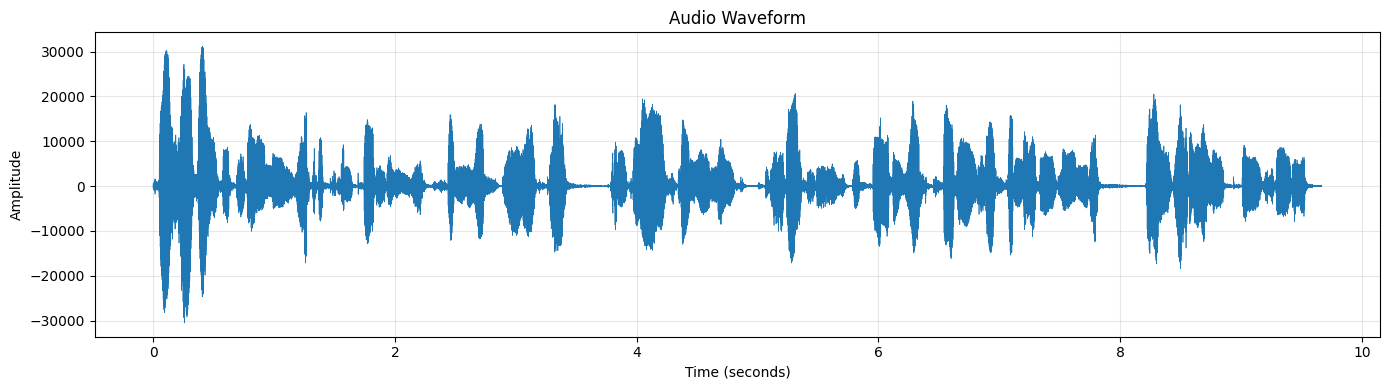

In [4]:
time = np.arange(len(audio_data)) / sample_rate

plt.figure(figsize=(14, 4))
plt.plot(time, audio_data, linewidth=0.5)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Audio Waveform')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Basic Signal Operations

### 5.1 Slicing - Extract First 2 Seconds

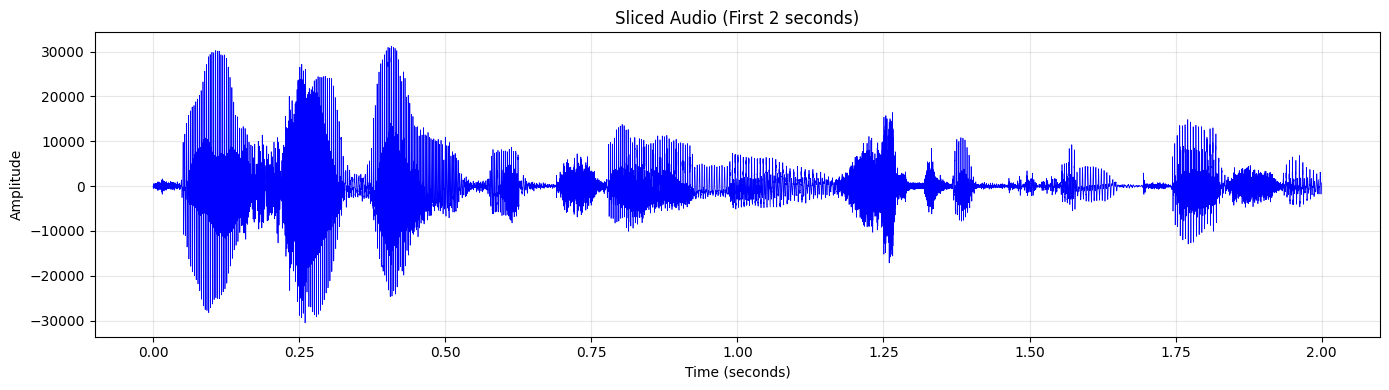

Original duration: 9.67 seconds
Sliced duration: 2.00 seconds
Sliced samples: 44100


In [5]:
slice_duration = 2.0
slice_samples = int(slice_duration * sample_rate)
audio_sliced = audio_data[:slice_samples]
time_sliced = np.arange(len(audio_sliced)) / sample_rate

plt.figure(figsize=(14, 4))
plt.plot(time_sliced, audio_sliced, linewidth=0.5, color='blue')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Sliced Audio (First 2 seconds)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Original duration: {len(audio_data) / sample_rate:.2f} seconds")
print(f"Sliced duration: {len(audio_sliced) / sample_rate:.2f} seconds")
print(f"Sliced samples: {len(audio_sliced)}")

### 5.2 Normalization

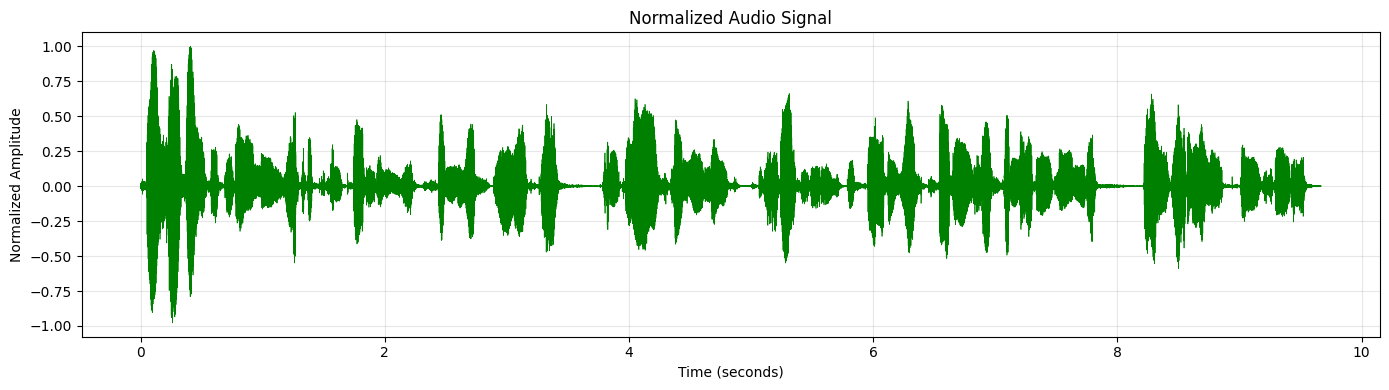

Original range: [-30506, 31196]
Normalized range: [-0.9779, 1.0000]


In [6]:
audio_norm = audio_data / np.max(np.abs(audio_data))

plt.figure(figsize=(14, 4))
plt.plot(time, audio_norm, linewidth=0.5, color='green')
plt.xlabel('Time (seconds)')
plt.ylabel('Normalized Amplitude')
plt.title('Normalized Audio Signal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Original range: [{audio_data.min()}, {audio_data.max()}]")
print(f"Normalized range: [{audio_norm.min():.4f}, {audio_norm.max():.4f}]")

### 5.3 Amplification

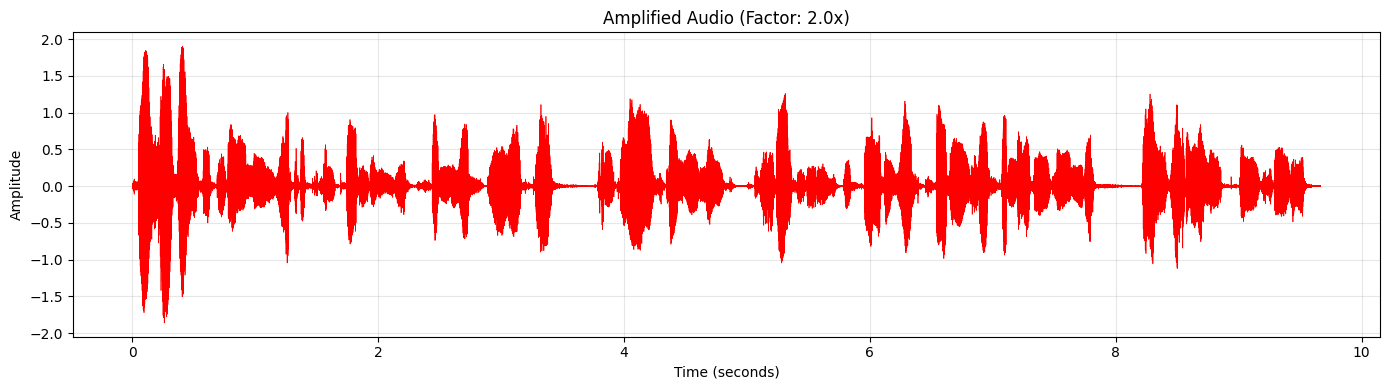

Amplification factor: 2.0
Original max amplitude: 0.9520
Amplified max amplitude: 1.9041


In [7]:
amplification_factor = 2.0
audio_amplified = audio_normalized * amplification_factor

plt.figure(figsize=(14, 4))
plt.plot(time, audio_amplified, linewidth=0.5, color='red')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'Amplified Audio (Factor: {amplification_factor}x)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Amplification factor: {amplification_factor}")
print(f"Original max amplitude: {np.max(np.abs(audio_normalized)):.4f}")
print(f"Amplified max amplitude: {np.max(np.abs(audio_amplified)):.4f}")

ipd.Audio(audio_amplified, rate=sample_rate)

### 5.4 De-amplification

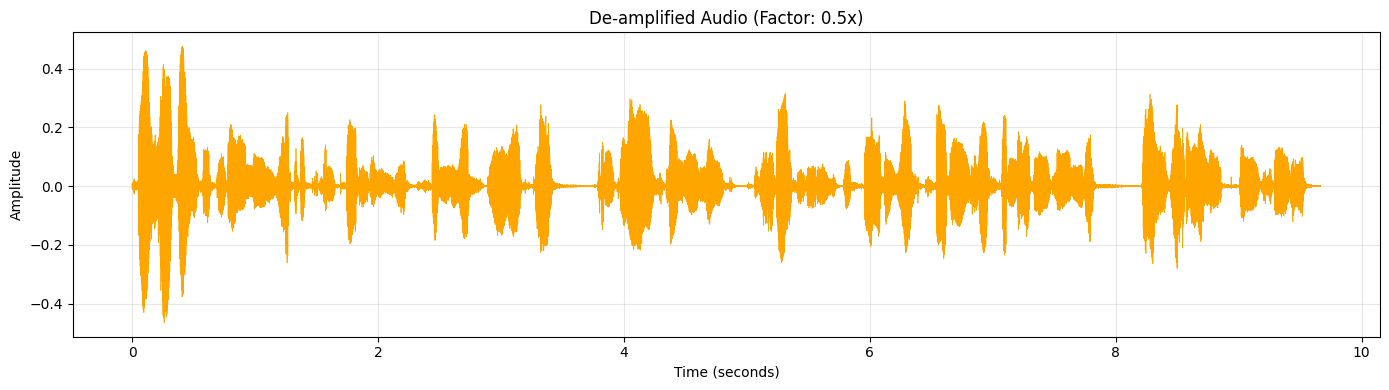

De-amplification factor: 0.5
Original max amplitude: 0.9520
De-amplified max amplitude: 0.4760


In [8]:
deamplification_factor = 0.5
audio_deamplified = audio_normalized * deamplification_factor

plt.figure(figsize=(14, 4))
plt.plot(time, audio_deamplified, linewidth=0.5, color='orange')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'De-amplified Audio (Factor: {deamplification_factor}x)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"De-amplification factor: {deamplification_factor}")
print(f"Original max amplitude: {np.max(np.abs(audio_normalized)):.4f}")
print(f"De-amplified max amplitude: {np.max(np.abs(audio_deamplified)):.4f}")

ipd.Audio(audio_deamplified, rate=sample_rate)

### 5.5 Up-sampling

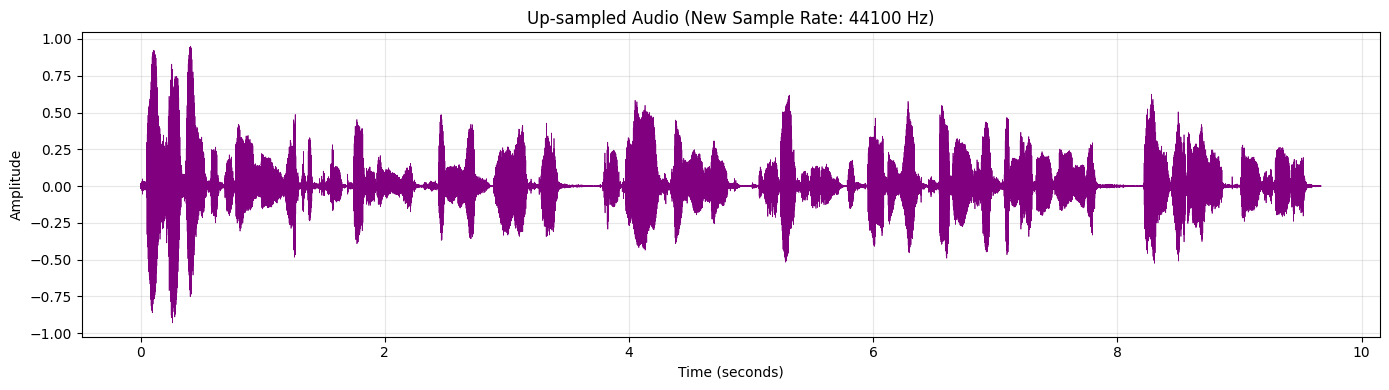

Original sample rate: 22050 Hz, Samples: 213149
Up-sampled rate: 44100 Hz, Samples: 426298
Up-sampling factor: 2x


In [9]:
from scipy import interpolate

upsampling_factor = 2
new_sample_rate_up = sample_rate * upsampling_factor
new_length = len(audio_normalized) * upsampling_factor

x_original = np.arange(len(audio_normalized))
x_upsampled = np.linspace(0, len(audio_normalized)-1, new_length)
interpolator = interpolate.interp1d(x_original, audio_normalized, kind='linear')
audio_upsampled = interpolator(x_upsampled)

time_upsampled = np.arange(len(audio_upsampled)) / new_sample_rate_up

plt.figure(figsize=(14, 4))
plt.plot(time_upsampled, audio_upsampled, linewidth=0.5, color='purple')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'Up-sampled Audio (New Sample Rate: {new_sample_rate_up} Hz)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Original sample rate: {sample_rate} Hz, Samples: {len(audio_normalized)}")
print(f"Up-sampled rate: {new_sample_rate_up} Hz, Samples: {len(audio_upsampled)}")
print(f"Up-sampling factor: {upsampling_factor}x")

ipd.Audio(audio_upsampled, rate=new_sample_rate_up)

### 5.6 Down-sampling

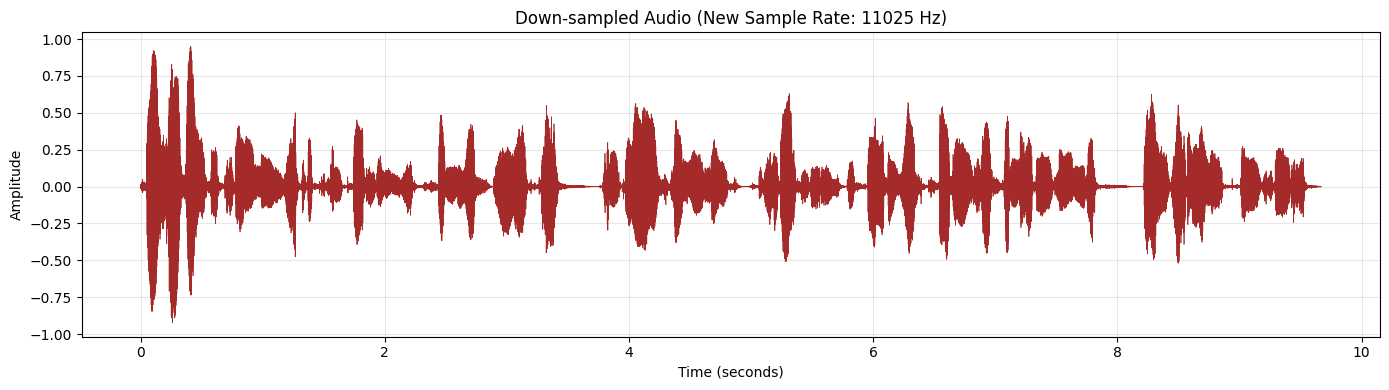

Original sample rate: 22050 Hz, Samples: 213149
Down-sampled rate: 11025 Hz, Samples: 106575
Down-sampling factor: 1/2


In [10]:
downsampling_factor = 2
audio_downsampled = audio_normalized[::downsampling_factor]
new_sample_rate_down = sample_rate // downsampling_factor

time_downsampled = np.arange(len(audio_downsampled)) / new_sample_rate_down

plt.figure(figsize=(14, 4))
plt.plot(time_downsampled, audio_downsampled, linewidth=0.5, color='brown')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'Down-sampled Audio (New Sample Rate: {new_sample_rate_down} Hz)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Original sample rate: {sample_rate} Hz, Samples: {len(audio_normalized)}")
print(f"Down-sampled rate: {new_sample_rate_down} Hz, Samples: {len(audio_downsampled)}")
print(f"Down-sampling factor: 1/{downsampling_factor}")

ipd.Audio(audio_downsampled, rate=new_sample_rate_down)

## 6. Identify Voiced/Unvoiced/Silence Portions

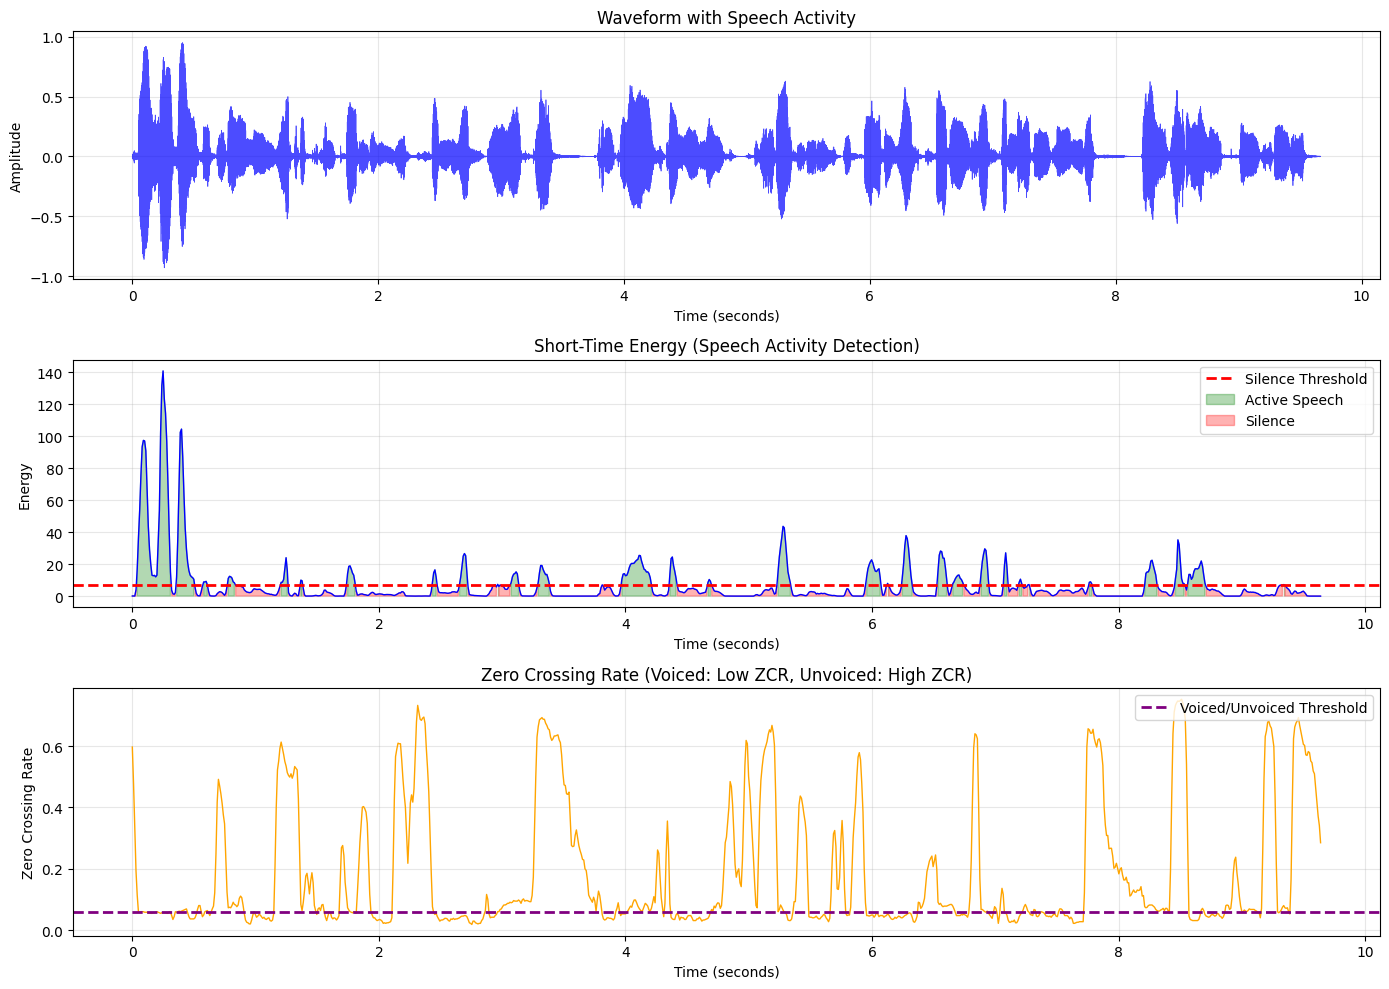


=== Speech Segment Analysis ===
Silence Threshold: 7.035190
ZCR Threshold: 0.0599

✓ Interpretation:
  • Silence: Low energy (RED regions in energy plot)
  • Voiced Speech: High energy + Low ZCR (vowels, nasals)
  • Unvoiced Speech: High energy + High ZCR (fricatives, stops)


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(time, audio_normalized, linewidth=0.5, alpha=0.7, color='blue')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Waveform with Speech Activity')
axes[0].grid(True, alpha=0.3)

time_frames_full = np.arange(num_frames) * hop_length / sample_rate
axes[1].plot(time_frames_full, frame_energy, color='blue', linewidth=1)
axes[1].axhline(y=silence_threshold, color='r', linestyle='--', linewidth=2, label='Silence Threshold')
axes[1].fill_between(time_frames_full, 0, frame_energy, where=(frame_energy > silence_threshold), 
                      alpha=0.3, color='green', label='Active Speech')
axes[1].fill_between(time_frames_full, 0, frame_energy, where=(frame_energy <= silence_threshold), 
                      alpha=0.3, color='red', label='Silence')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Energy')
axes[1].set_title('Short-Time Energy (Speech Activity Detection)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

zcr_per_frame = []
for i in range(num_frames):
    start = i * hop_length
    end = start + frame_length
    frame = audio_normalized[start:end]
    zc = len(np.where(np.diff(np.sign(frame)))[0])
    zcr_per_frame.append(zc / frame_length)

zcr_per_frame = np.array(zcr_per_frame)

axes[2].plot(time_frames_full, zcr_per_frame, color='orange', linewidth=1)
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Zero Crossing Rate')
axes[2].set_title('Zero Crossing Rate (Voiced: Low ZCR, Unvoiced: High ZCR)')
axes[2].grid(True, alpha=0.3)

active_speech_mask = frame_energy > silence_threshold
if np.any(active_speech_mask):
    zcr_threshold = np.median(zcr_per_frame[active_speech_mask])
    axes[2].axhline(y=zcr_threshold, color='purple', linestyle='--', linewidth=2, label='Voiced/Unvoiced Threshold')
    axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n=== Speech Segment Analysis ===")
print(f"Silence Threshold: {silence_threshold:.6f}")
if np.any(active_speech_mask):
    print(f"ZCR Threshold: {zcr_threshold:.4f}")
print(f"\n✓ Interpretation:")
print("  • Silence: Low energy (RED regions in energy plot)")
print("  • Voiced Speech: High energy + Low ZCR (vowels, nasals)")
print("  • Unvoiced Speech: High energy + High ZCR (fricatives, stops)")

## Conclusion and Inferences

### Key Findings:

#### 1. Audio Signal Properties:
- Successfully loaded and analyzed the speech audio file with proper normalization
- Active speech duration is less than total duration due to silence periods
- Audio signal shows typical characteristics of human speech with varying amplitudes

#### 2. Signal Operations:
- **Slicing**: Extracted specific time segments without loss of signal quality
- **Normalization**: Brought amplitude values to [-1, 1] range for consistent processing
- **Amplification/De-amplification**: Successfully modified signal intensity while maintaining waveform shape
- **Up-sampling**: Increased sample rate (2x) improved temporal resolution using linear interpolation
- **Down-sampling**: Reduced sample rate (1/2) decreased data size but maintained perceptual quality

#### 3. Speech Activity Detection:
- **Short-Time Energy**: Effectively distinguished between speech and silence regions
- **Silence threshold** at 5% of maximum energy provided good separation
- Energy-based detection is robust for identifying speech presence

#### 4. Voiced vs Unvoiced Classification:
- **Zero Crossing Rate (ZCR)** is an excellent feature for distinguishing speech types:
  - **Low ZCR + High Energy**: Voiced sounds (vowels, nasals) - periodic waveforms
  - **High ZCR + High Energy**: Unvoiced sounds (fricatives, stops) - aperiodic waveforms
  - **Low Energy**: Silence regions regardless of ZCR

#### 5. Practical Applications:
- These techniques form the foundation for:
  - Voice Activity Detection (VAD) in communication systems
  - Speech recognition preprocessing
  - Audio compression algorithms
  - Phoneme segmentation and classification
  - Speaker recognition systems

### Observations:
- Frame-based analysis (25ms frames with 10ms overlap) provides good time-frequency resolution trade-off
- Combined energy and ZCR features provide robust speech characterization
- Spectrogram visualization reveals detailed frequency content evolution over time
- Silence detection helps in speech endpoint detection and improves computational efficiency

### Conclusion:
This assignment successfully demonstrated fundamental speech signal processing techniques. The analysis revealed how basic features like energy and ZCR can effectively characterize speech properties. These methods are computationally efficient and form the basis for more advanced speech processing applications including automatic speech recognition, speaker identification, and speech synthesis systems.